In [ ]:
# Mutual Fund Analytics Capstone Project
## Exploratory Data Analysis (EDA)


### Objective
#To analyze mutual fund data from 2022–2025 and 
#identify trends in NAV, AUM, SIP inflows, investor demographics, portfolio allocation, and folio growth using Python.

In [5]:
import plotly
import kaleido

print("Plotly version:", plotly.__version__)
print("Kaleido module:", kaleido)

Plotly version: 6.8.0
Kaleido module: <module 'kaleido' from 'c:\\Users\\USER\\Desktop\\Mutual Fund Analytics-project\\.venv\\Lib\\site-packages\\kaleido\\__init__.py'>


In [1]:
# impoort necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

sns.set_style("whitegrid")

In [2]:
#load datasets
import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/raw/02_nav_history.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

In [ ]:
## Data Cleaning

#The datasets were cleaned before analysis:
#- Converted date columns to datetime format.
#- Removed duplicate records.
#- Checked for missing values.
#- Validated numerical columns.
#- Standardized categorical values.

In [8]:
nav["date"] = pd.to_datetime(nav["date"])

In [9]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [ ]:
#chart1: Daily nav trend
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.show()
fig.write_image("../reports/charts/nav_trend.png")

In [13]:
aum["date"] = pd.to_datetime(aum["date"])

In [16]:
aum["year"] = aum["date"].dt.year
aum[["date", "year"]].head()

,date,year
0,2022-03-31,2022
1,2022-03-31,2022
2,2022-03-31,2022
3,2022-03-31,2022
4,2022-03-31,2022


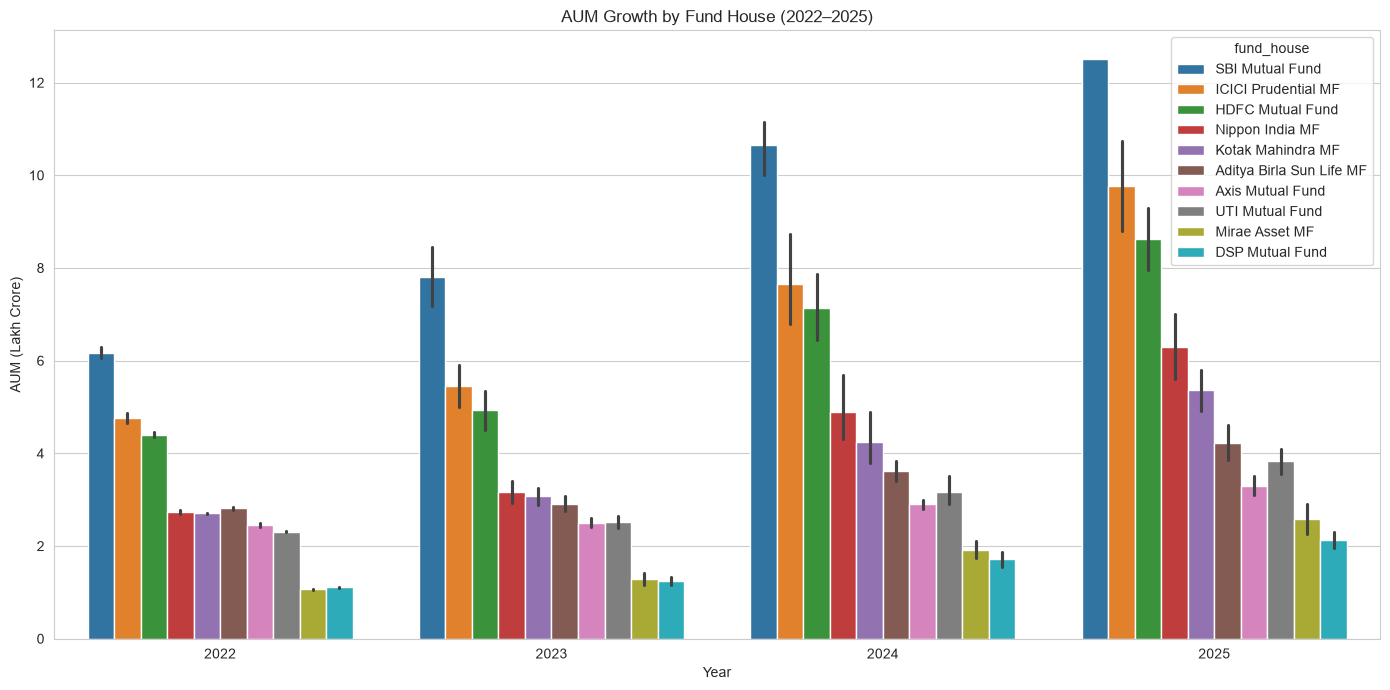

<Figure size 640x480 with 0 Axes>

In [ ]:
# Chart 2: AUM Growth by Fund Houseimport matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
plt.savefig("../reports/charts/aum_growth.png", dpi=300, bbox_inches="tight")

In [21]:
sip["month"] = pd.to_datetime(sip["month"])


In [ ]:
#chart3:sip monthly trend
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

fig.show()

In [42]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)"
)

fig.add_annotation(
    x=pd.to_datetime("2025-12-01"),
    y=31002,
    text="₹31,002 Cr (Dec 2025)",
    showarrow=True,
    arrowhead=2
)

fig.show()
plt.savefig("../reports/charts/sip_inflow_trend.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [27]:
category["month"] = pd.to_datetime(category["month"])

In [30]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

In [33]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


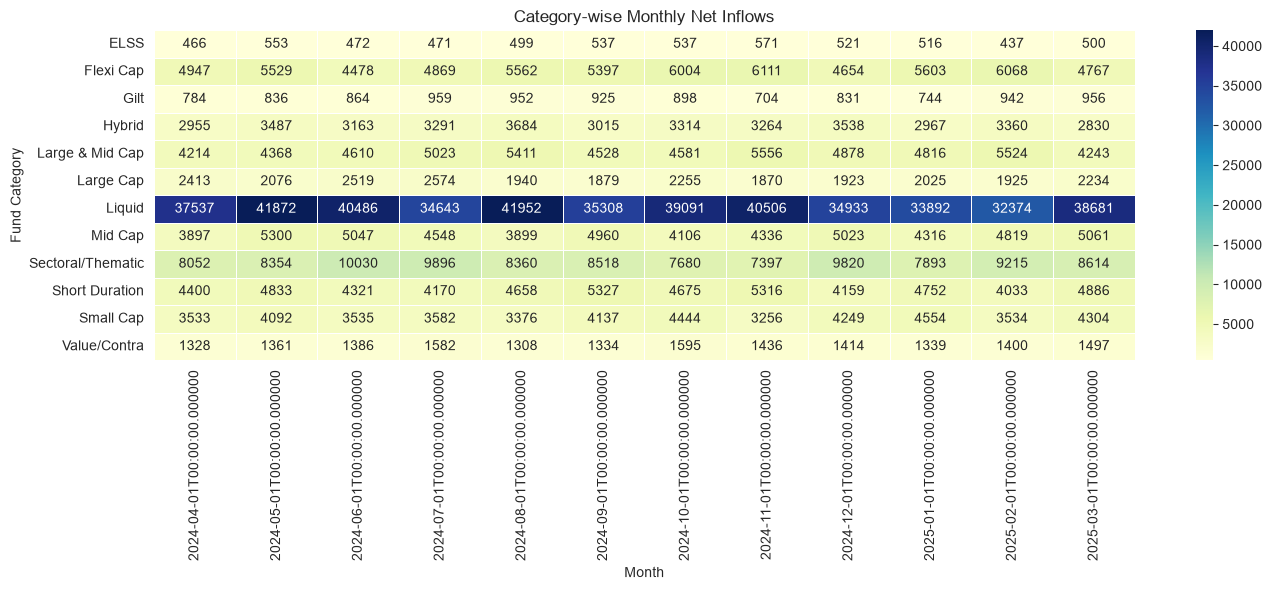

<Figure size 640x480 with 0 Axes>

In [ ]:
#chart 4: category inflow heatmap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot heatmap
plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("../reports/charts/category_inflow_heatmap.png", dpi=300)

plt.show()
plt.savefig(
    "../reports/charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

In [39]:
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

sector_weights.head()

,sector,weight_pct
0,Banking,652.26
1,IT,455.47
2,Pharma,407.45
3,Automobile,323.65
4,Utilities,265.54


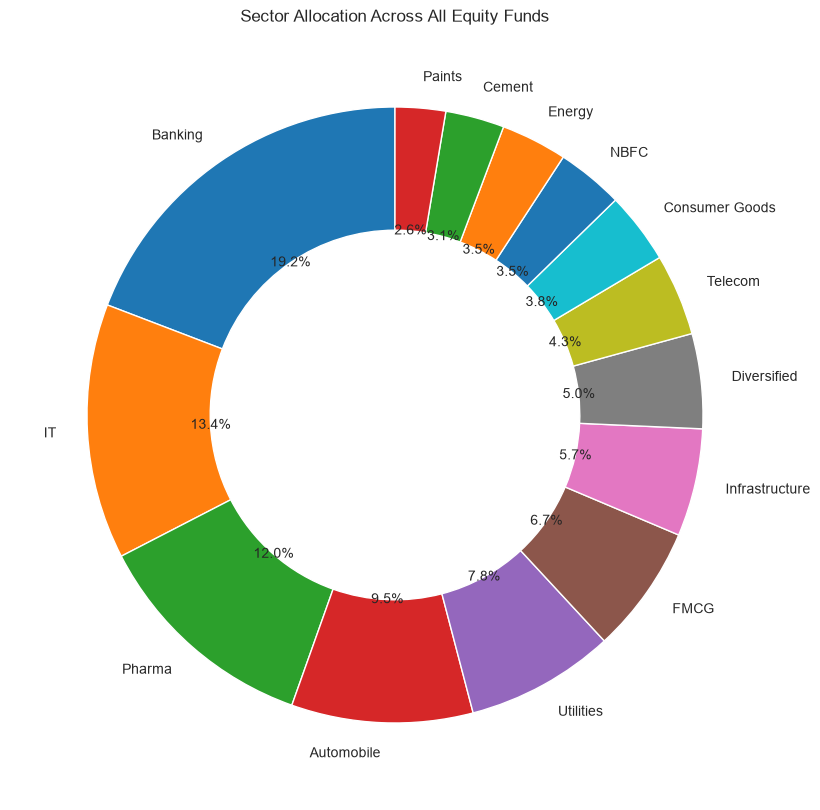

<Figure size 640x480 with 0 Axes>

In [ ]:
#chart 5:sector Allocation Donut chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.pie(
    sector_weights["weight_pct"],
    labels=sector_weights["sector"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation Across All Equity Funds")

plt.savefig(
    "../reports/charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.savefig("../reports/charts/sector_allocation_donut.png", dpi=300, bbox_inches="tight")

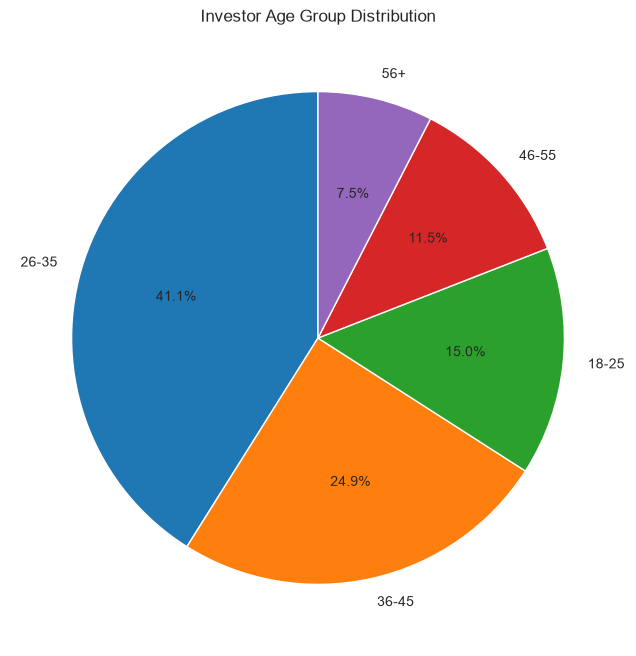

In [ ]:
#chart 6: age group distribution
import matplotlib.pyplot as plt

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

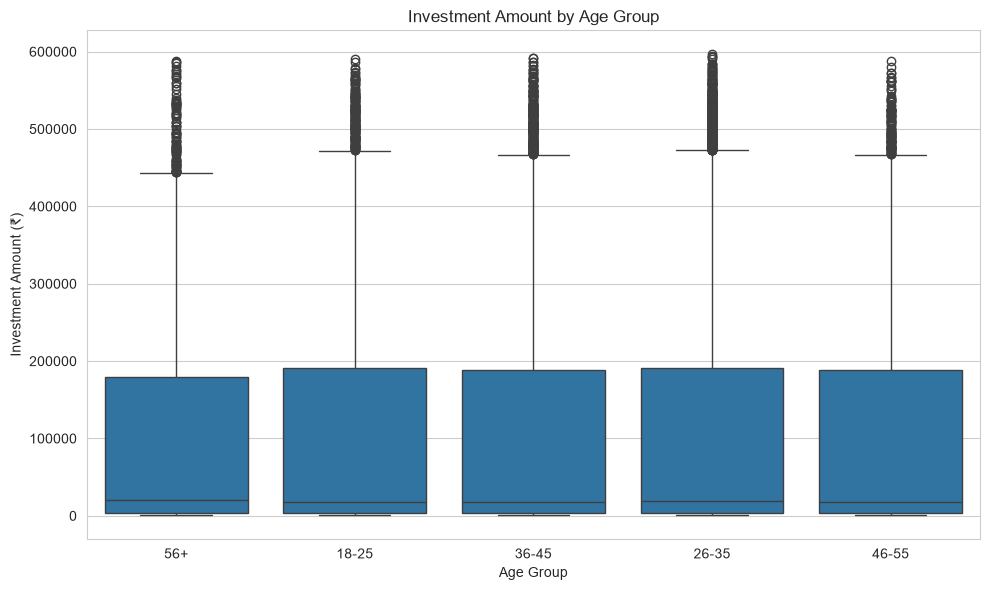

In [ ]:
#chart 7: sip amount Box plot by Age group
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

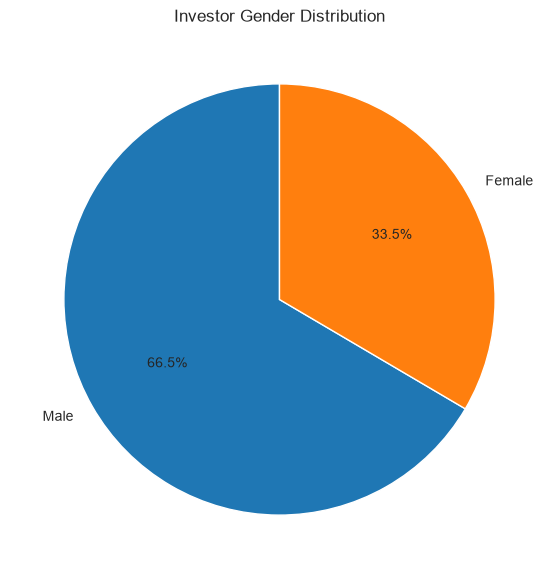

In [ ]:
# chart 8: gender Distribution
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Gender Distribution")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

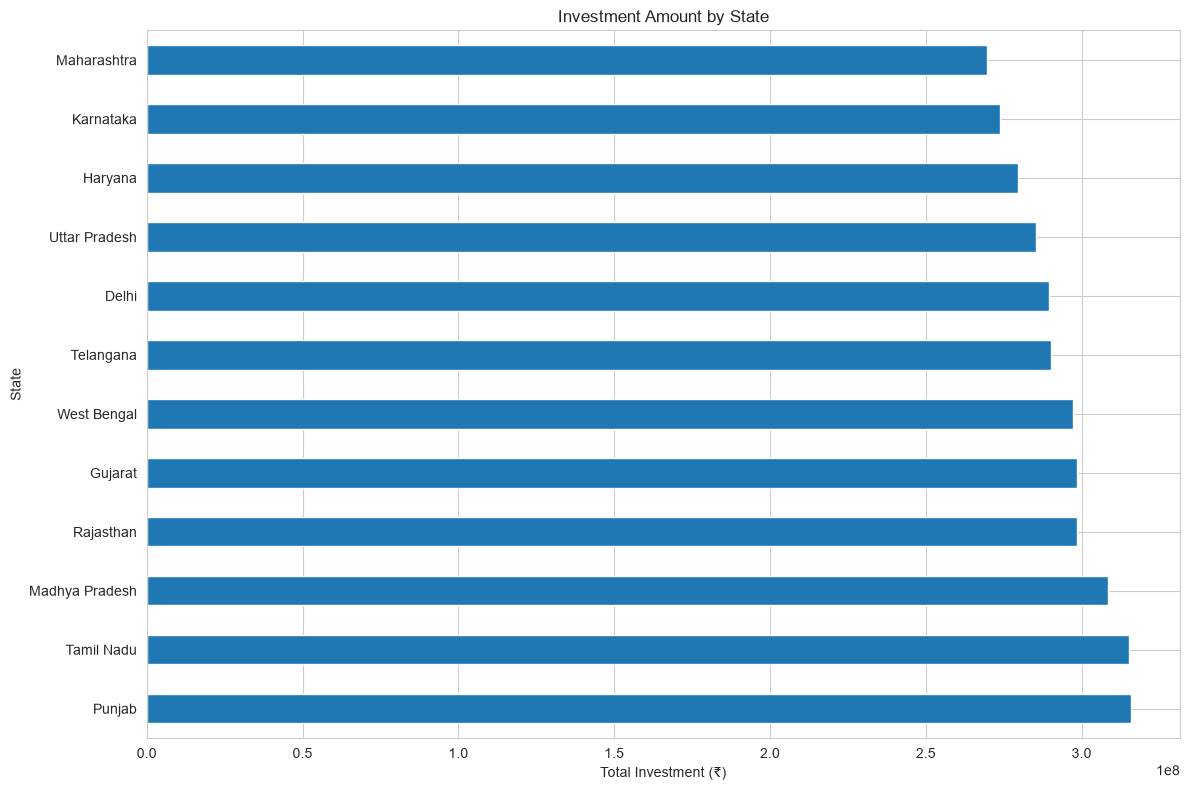

In [ ]:
#chart 9: sip amount bystate
state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_amount.plot(kind="barh")

plt.title("Investment Amount by State")
plt.xlabel("Total Investment (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/charts/state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

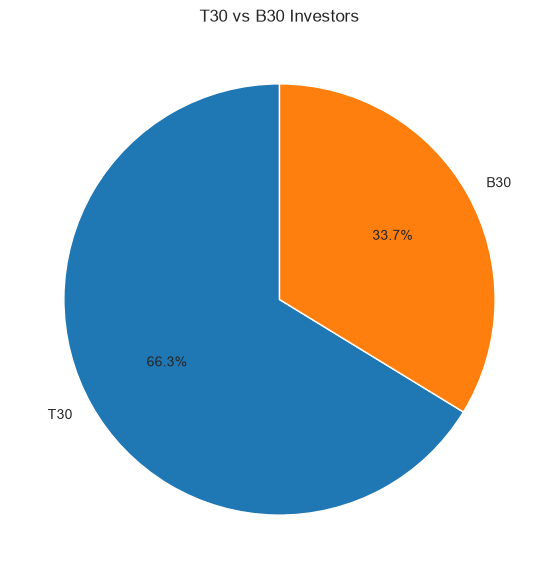

In [ ]:
# chart 10: city tier distribution
city_tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investors")

plt.savefig(
    "../reports/charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

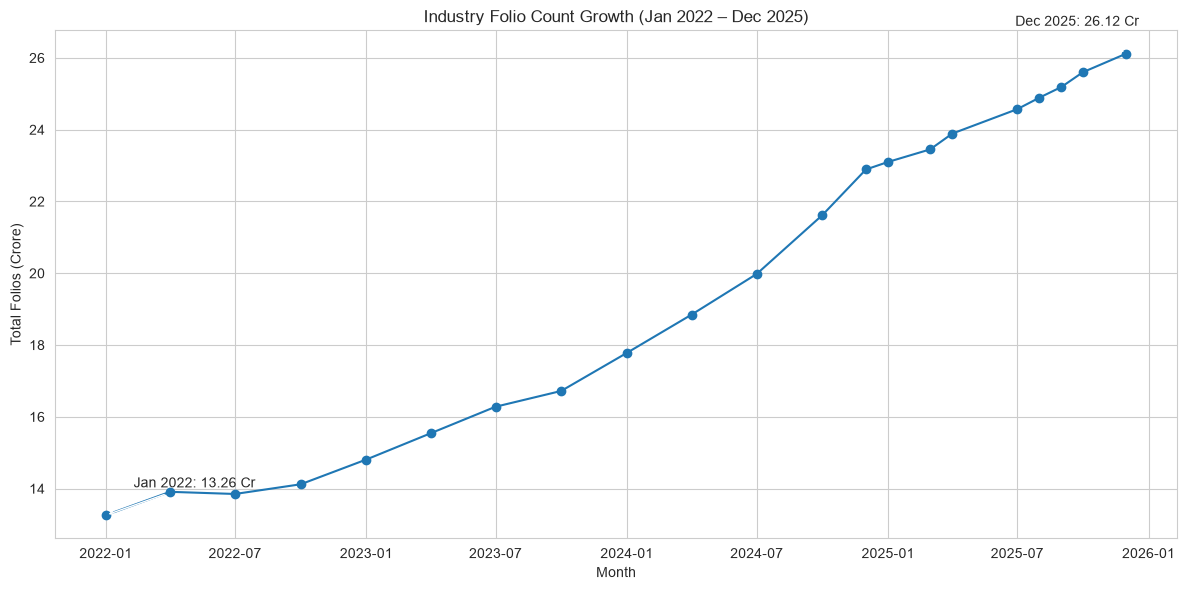

In [5]:
#chart 11: folio count growth
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Count Growth (Jan 2022 – Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.annotate(
    "Jan 2022: 13.26 Cr",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0]),
    xytext=(20,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "Dec 2025: 26.12 Cr",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1]),
    xytext=(-80,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

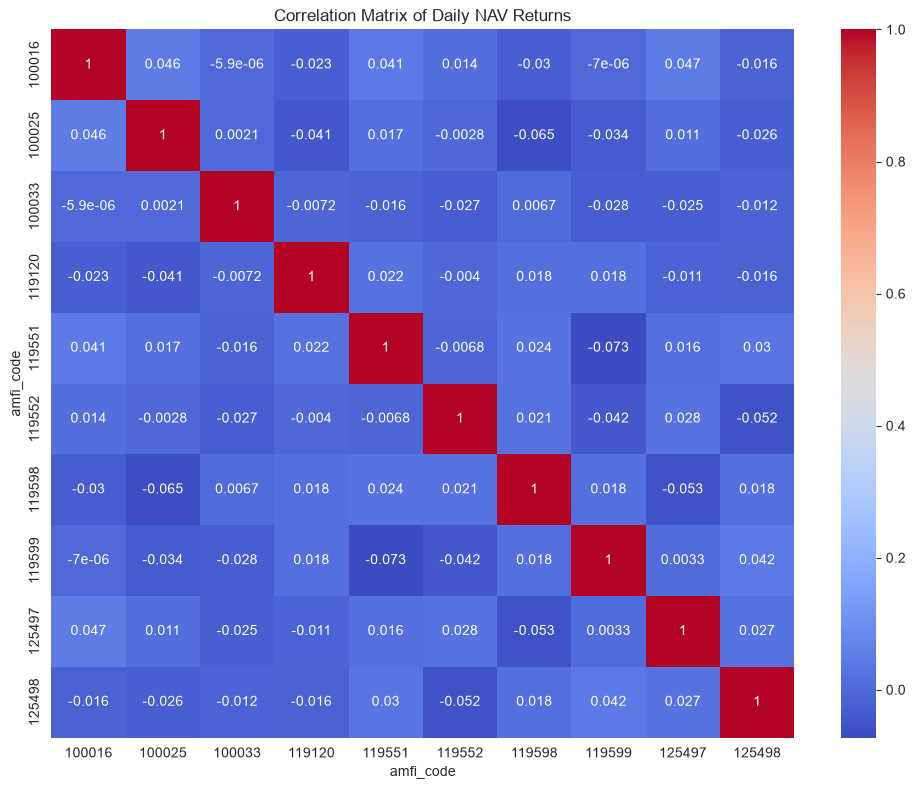

In [ ]:
#chart 12: nav correlation heatmap
nav["date"] = pd.to_datetime(nav["date"])

top10 = nav["amfi_code"].unique()[:10]

nav_corr = nav[nav["amfi_code"].isin(top10)]

pivot = nav_corr.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig(
    "../reports/charts/nav_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

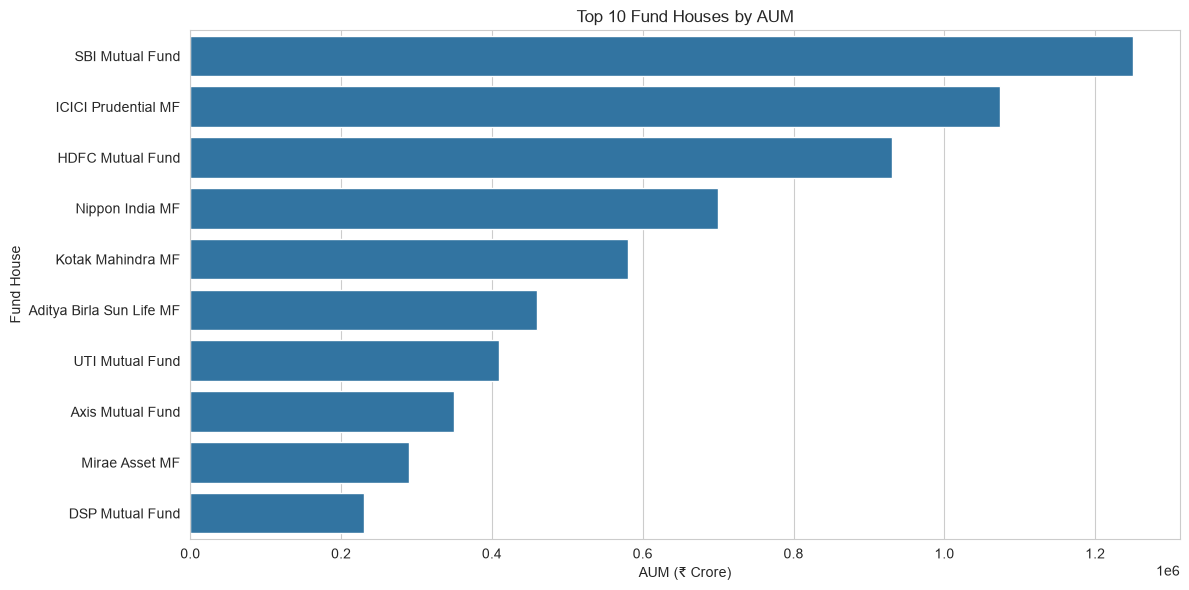

In [ ]:
# chart 13: Top 10 Fund Houses by AUM
import matplotlib.pyplot as plt
import seaborn as sns

latest = aum.sort_values("date").groupby("fund_house").tail(1)

top10 = latest.nlargest(10, "aum_crore")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="aum_crore",
    y="fund_house"
)

plt.title("Top 10 Fund Houses by AUM")
plt.xlabel("AUM (₹ Crore)")
plt.ylabel("Fund House")

plt.tight_layout()

plt.savefig("../reports/charts/top10_fundhouses_aum.png", dpi=300)

plt.show()

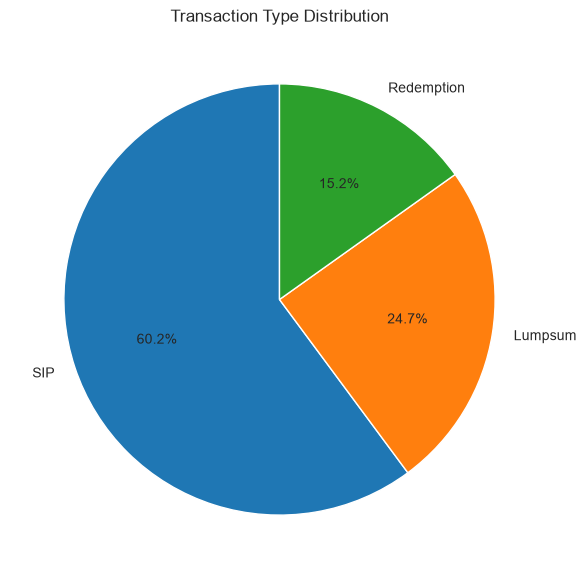

In [ ]:
# chart 14: transaction type distribution
transaction_counts = transactions["transaction_type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    transaction_counts,
    labels=transaction_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Transaction Type Distribution")

plt.savefig("../reports/charts/transaction_type_distribution.png", dpi=300)

plt.show()

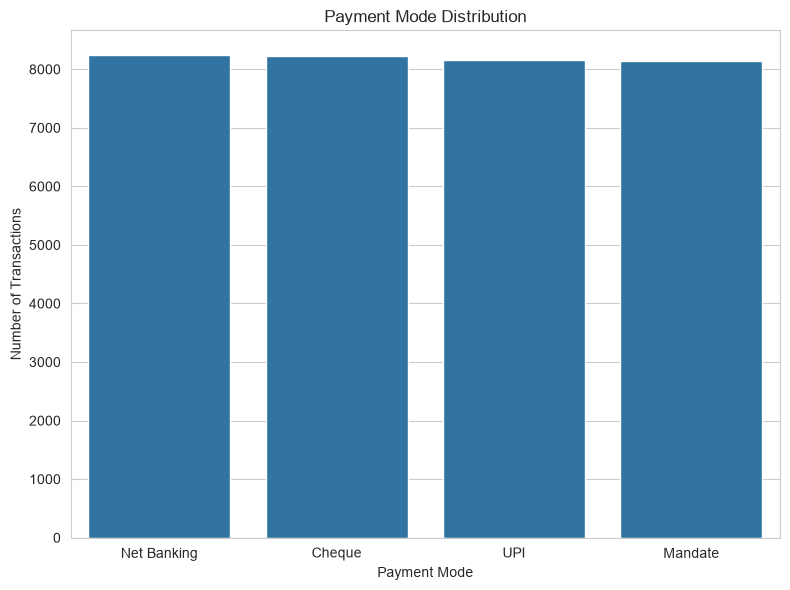

In [ ]:
#chart 15: payment mode distribution
payment = transactions["payment_mode"].value_counts()

plt.figure(figsize=(8,6))

sns.barplot(
    x=payment.index,
    y=payment.values
)

plt.title("Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../reports/charts/payment_mode_distribution.png", dpi=300)

plt.show()

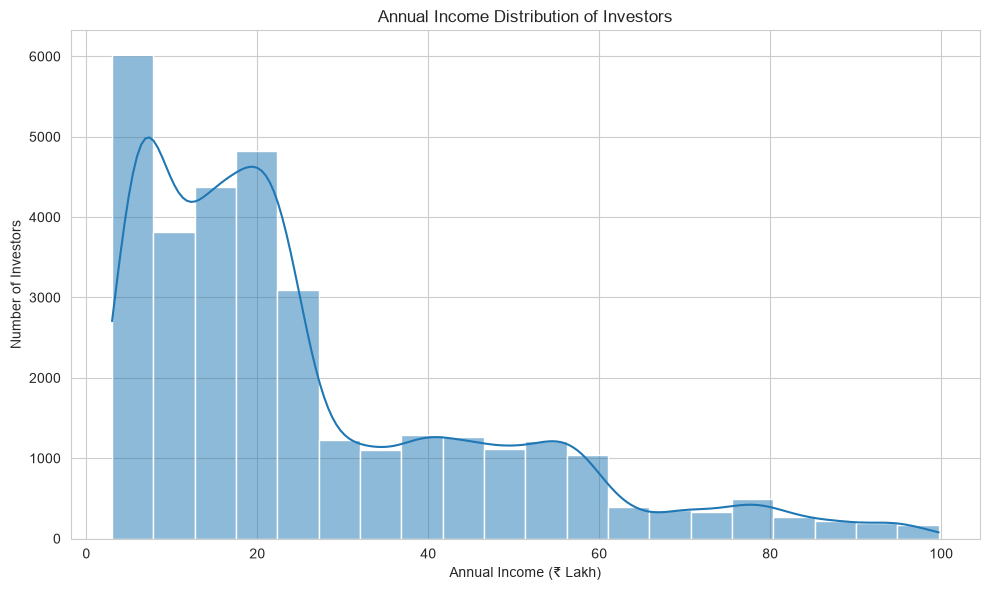

In [ ]:
# chart 16: annual income distribution
plt.figure(figsize=(10,6))

sns.histplot(
    transactions["annual_income_lakh"],
    bins=20,
    kde=True
)

plt.title("Annual Income Distribution of Investors")
plt.xlabel("Annual Income (₹ Lakh)")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig("../reports/charts/income_distribution.png", dpi=300)

plt.show()